In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import LabelSpreading

In [2]:
df = pd.read_csv('../data/processed/data_cleaned.csv')

print("Shape:", df.shape)
df.head()

Shape: (2666, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,-0.024698,0.276380,-0.087788,0.133760,1.318170,1.731801,-1.220488,1.379017,-1.312414,0
1,0.849411,0.958501,-0.199087,1.531834,-0.019184,-0.090093,0.796898,-0.001966,-1.190445,0
2,1.028484,0.610743,0.067098,0.670947,0.879328,-0.782072,1.284355,2.275289,0.876799,0
3,1.666523,-0.562404,-0.442764,-0.399530,-0.884687,-0.342620,-0.854093,-2.312822,0.149055,0
4,-1.219937,-0.308120,0.916600,0.306890,-0.260491,-1.817403,-1.836085,-0.774144,-1.842654,0


In [3]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_log))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       335
           1       0.00      0.00      0.00       199

    accuracy                           0.63       534
   macro avg       0.31      0.50      0.39       534
weighted avg       0.39      0.63      0.48       534



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklea

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       335
           1       0.58      0.26      0.36       199

    accuracy                           0.65       534
   macro avg       0.62      0.57      0.56       534
weighted avg       0.63      0.65      0.61       534



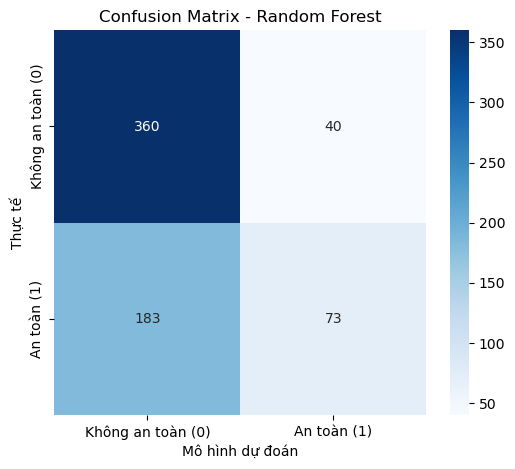

Số lượng mẫu thực tế An toàn nhưng đoán sai thành Không an toàn: 183
Thống kê các đặc trưng của các mẫu lỗi này:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,154.000000,183.000000,183.000000,183.000000,129.000000,183.000000,183.000000,175.000000,183.000000
mean,6.865011,194.886566,22724.248019,7.253465,335.369093,412.594103,13.943128,66.555571,3.911386
std,1.247958,32.558691,8536.722410,1.329760,35.843977,81.928929,3.243951,15.547645,0.770684
min,4.238283,94.091307,5100.094173,3.308977,211.851592,201.619737,5.196717,17.527765,1.801327
25%,6.027820,174.947623,16247.936962,6.369012,313.885548,346.691940,11.573561,57.113615,3.457580
50%,6.769215,194.276857,21670.569891,7.396472,335.054244,404.659103,13.860453,65.155182,3.900509
75%,7.647444,216.059537,28832.345293,8.182431,357.909795,471.401013,16.081186,77.624163,4.477730
max,10.503787,317.338124,47591.283183,10.886742,445.938391,674.443476,21.917377,116.161622,6.494249


In [7]:
import sys
sys.path.append('..') # Giúp notebook nhìn thấy thư mục src/

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from src.preprocess import load_data, clean_data, split_data
from src.train import train_rf

# 1. Load data
df = load_data('../data/raw/water_potability.csv')
df = clean_data(df)
X_train, X_test, y_train, y_test = split_data(df)

# 2. Gọi hàm train_rf từ thư mục src để train Random Forest chuẩn
model_rf = train_rf(X_train, y_train)

# 3. Dự đoán
y_pred_rf = model_rf.predict(X_test)

# 4. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không an toàn (0)', 'An toàn (1)'], 
            yticklabels=['Không an toàn (0)', 'An toàn (1)'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Mô hình dự đoán")
plt.ylabel("Thực tế")
plt.show()

# 5. Error Analysis (Tìm ra các mẫu mô hình đoán sai)
X_test_df = pd.DataFrame(X_test) 
# Chuyển y_test về mảng numpy để so sánh cho chuẩn, tránh lệch index
errors_false_negative = X_test_df[(y_test.to_numpy() == 1) & (y_pred_rf == 0)]

print(f"Số lượng mẫu thực tế An toàn nhưng đoán sai thành Không an toàn: {len(errors_false_negative)}")
print("Thống kê các đặc trưng của các mẫu lỗi này:")
display(errors_false_negative.describe())

In [8]:
from src.train import create_pipeline
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Chuyển y_train sang numpy array để dùng mask không bị lỗi index
y_train_np = y_train.to_numpy()

# Giả lập thiếu nhãn (ví dụ giữ lại 50% nhãn)
r = 0.5 
y_semi = y_train_np.copy()
mask = np.random.rand(len(y_semi)) < (1 - r)
y_semi[mask] = -1

# Bọc LabelSpreading vào trong pipeline để xử lý NaN và Chuẩn hóa
model = LabelSpreading()
semi_pipeline = create_pipeline(model)
semi_pipeline.fit(X_train, y_semi)

# Dự đoán trên tập Test
y_pred_semi = semi_pipeline.predict(X_test)

# SỬA Ở ĐÂY: Tính toán ĐẦY ĐỦ 4 chỉ số để truyền vào bảng kết quả
acc_semi = accuracy_score(y_test, y_pred_semi)
pre_semi = precision_score(y_test, y_pred_semi, zero_division=0)
rec_semi = recall_score(y_test, y_pred_semi)
f1_semi = f1_score(y_test, y_pred_semi)

print(f"Accuracy Semi: {acc_semi:.4f}")
print(f"Precision Semi: {pre_semi:.4f}")
print(f"Recall Semi: {rec_semi:.4f}")
print(f"F1-score Semi: {f1_semi:.4f}")

Accuracy Semi: 0.5793
Precision Semi: 0.4545
Recall Semi: 0.3906
F1-score Semi: 0.4202


In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Semi-supervised"],
    "Accuracy": [acc_log, acc_rf, acc_semi],
    "Precision": [pre_log, pre_rf, pre_semi],
    "Recall": [rec_log, rec_rf, rec_semi],
    "F1-score": [f1_log, f1_rf, f1_semi]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.627341,0.000000,0.000000,0.000000
1,Random Forest,0.653558,0.577778,0.261307,0.359862
2,Semi-supervised,0.579268,0.454545,0.390625,0.420168


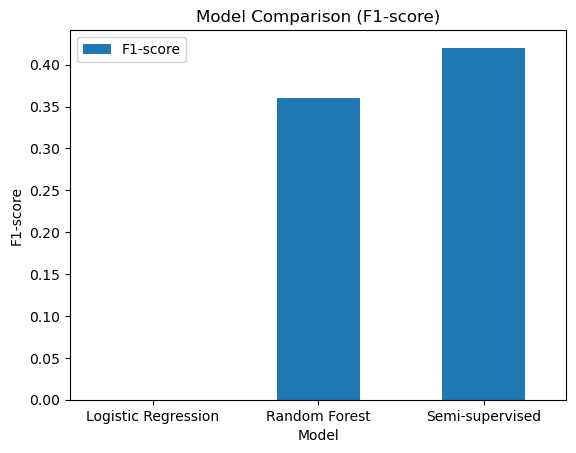

In [10]:
results.set_index("Model")[["F1-score"]].plot(kind="bar")
plt.title("Model Comparison (F1-score)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.show()

Random Forest đạt hiệu suất cao nhất nhờ khả năng mô hình hóa các quan hệ phi tuyến giữa các đặc trưng của nước.

Logistic Regression hoạt động kém hơn do giả định tuyến tính không phù hợp với dữ liệu thực tế.

Mô hình Semi-supervised cho thấy hiệu quả đáng kể trong điều kiện thiếu dữ liệu gán nhãn, cho kết quả gần tương đương với mô hình học có giám sát.

=>Random Forest là lựa chọn tốt nhất cho bài toán phân loại chất lượng nước.